Path to dataset files: /root/.cache/kagglehub/datasets/tbyrnes/advertising/versions/1

CSV files found:
['advertising.csv']

Dataset loaded successfully!

FIRST 5 ROWS
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   

                           Ad Topic Line            City  Male     Country  \
0     Cloned 5thgeneration orchestration     Wrightburgh     0     Tunisia   
1     Monitored national standardization       West Jodi     1       Nauru   
2       Organic bottom-line service-desk        Davidton     0  San Marino   
3  Triple-buffered reciprocal time-frame  West Terrifurt     1       Italy   
4          Robu

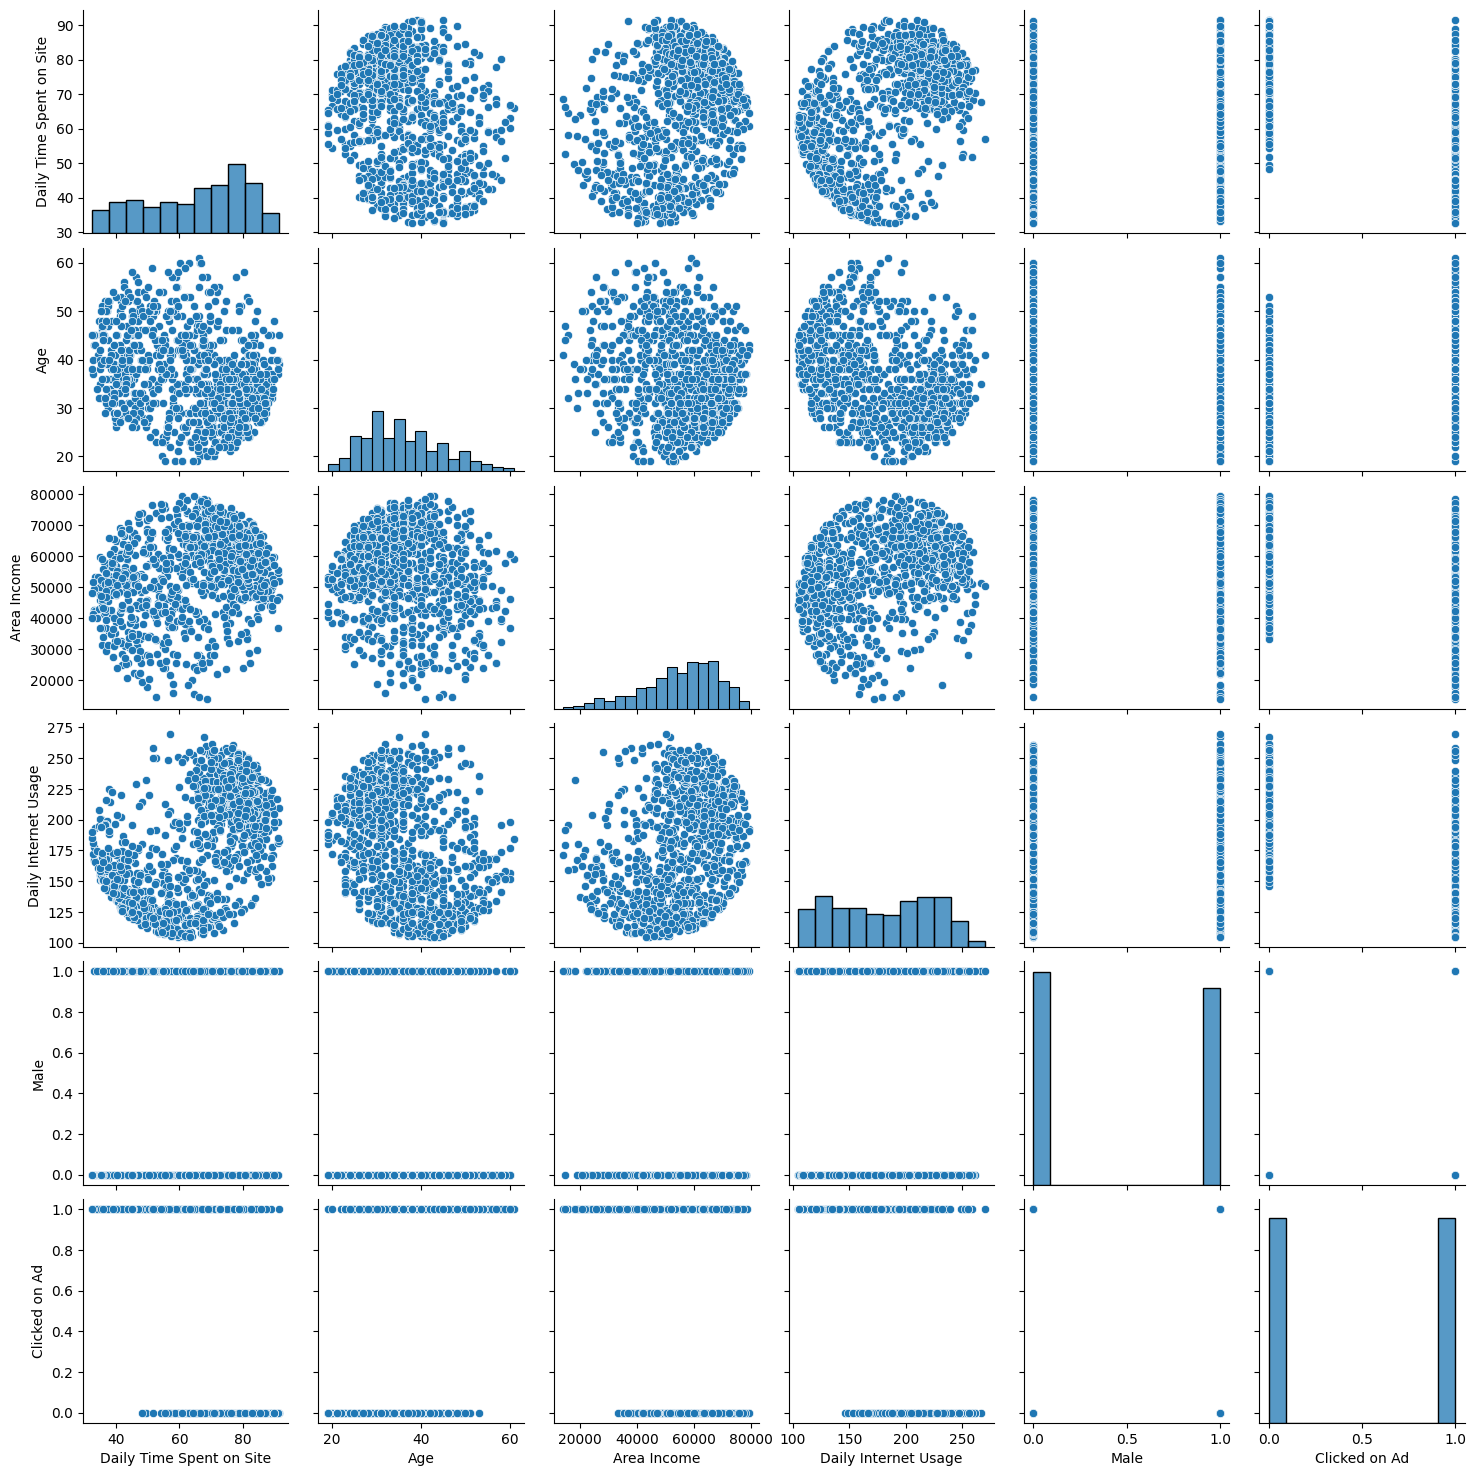


TRAIN-TEST SPLIT
Training data: (800, 5)
Testing data : (200, 5)

LINEAR REGRESSION
Linear Regression Predictions:
[ 7.69781982e-01  9.85029569e-01  9.54338681e-01  8.09301768e-01
  6.19307102e-02  3.95085393e-01  1.03485875e-01  1.06254388e+00
 -3.33132442e-02  1.14397744e+00 -6.32961273e-02  9.70033819e-01
  1.13126037e+00  7.11682629e-02  9.61874864e-01  1.15858903e+00
  1.21923734e+00  8.83075272e-01  1.91429590e-01  1.10650573e+00
 -1.72388408e-02  7.75586515e-01  1.14805594e+00  2.73402217e-01
 -9.98812498e-03  1.20172787e+00  9.57339841e-02 -5.38042667e-02
  1.14234949e+00  9.10675655e-01  2.14784299e-01  4.50475753e-01
  1.07623228e-02  7.66668794e-01  1.14309254e+00  9.69948835e-02
  2.74015942e-02  5.01022410e-01  8.96069009e-01  1.16457950e+00
  1.00701808e-01  1.06532904e+00  4.13704138e-01  1.15815576e+00
  4.87591117e-02  1.94788694e-01  7.11353326e-01  1.18630870e+00
  3.29356171e-01  1.04095526e+00  1.20433894e+00  1.46196998e-01
  9.54328708e-01  1.24124626e-01  3.459

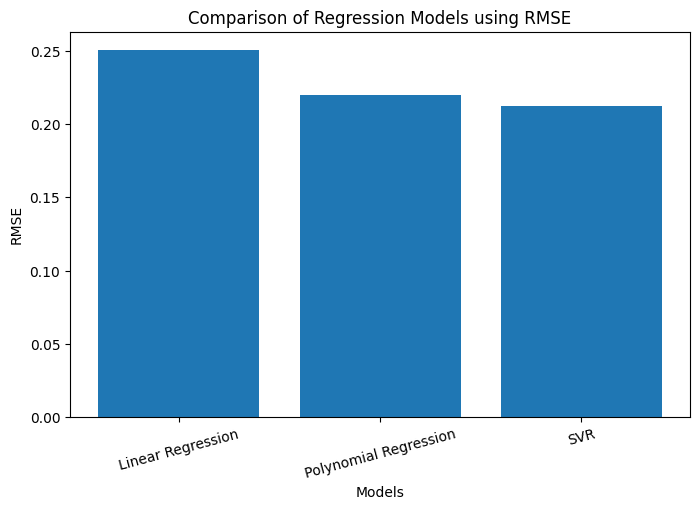


K-MEANS CLUSTERING

DATASET WITH CLUSTER LABELS
   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  \
0                     68.95   35     61833.90                256.09   
1                     80.23   31     68441.85                193.77   
2                     69.47   26     59785.94                236.50   
3                     74.15   29     54806.18                245.89   
4                     68.37   35     73889.99                225.58   
5                     59.99   23     59761.56                226.74   
6                     88.91   33     53852.85                208.36   
7                     66.00   48     24593.33                131.76   
8                     74.53   30     68862.00                221.51   
9                     69.88   20     55642.32                183.82   

                           Ad Topic Line              City  Male     Country  \
0     Cloned 5thgeneration orchestration       Wrightburgh     0     Tunisia   
1     Mon

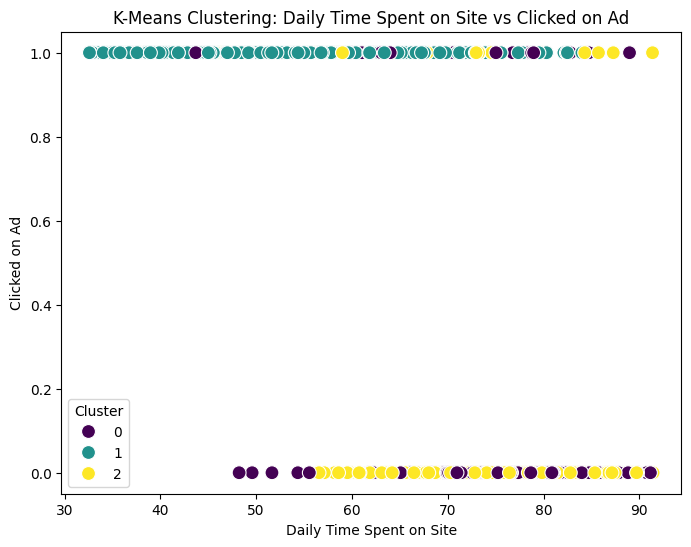


BEST REGRESSION MODEL
Best model based on RMSE: SVR

CONCLUSION
Linear Regression, Polynomial Regression,
and Support Vector Regression were trained.
MAE, MSE and RMSE were used to evaluate
the regression models.
K-Means clustering was performed with
3 clusters.
The clusters were visualized using
TV advertising versus Sales.


In [9]:
# ============================================================
# EX 3: MODEL PLANNING AND BUILDING
# AD23532 - PRINCIPLES OF DATA SCIENCE
# DATASET: ADVERTISING
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans


# ============================================================
# 2. DOWNLOAD ADVERTISING DATASET FROM KAGGLE
# ============================================================

path = kagglehub.dataset_download("tbyrnes/advertising")

print("Path to dataset files:", path)


# ============================================================
# 3. FIND THE CSV FILE
# ============================================================

csv_files = [
    f for f in os.listdir(path)
        if f.lower().endswith(".csv")
        ]

print("\nCSV files found:")
print(csv_files)


# ============================================================
# 4. LOAD DATASET
# ============================================================

file_path = os.path.join(path, csv_files[0])

df = pd.read_csv(file_path)

print("\nDataset loaded successfully!")


# ============================================================
# 5. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFIRST 5 ROWS")
print("============")

print(df.head())


# ============================================================
# 6. CHECK DATASET SHAPE
# ============================================================

print("\nDATASET SHAPE")
print("=============")

print(df.shape)


# ============================================================
# 7. CHECK COLUMN NAMES
# ============================================================

print("\nCOLUMN NAMES")
print("============")

print(df.columns)


# ============================================================
# 8. CHECK DATA TYPES
# ============================================================

print("\nDATA TYPES")
print("==========")
print(df.dtypes)


# ============================================================
# 9. CHECK NULL VALUES
# ============================================================

print("\nNULL VALUES")
print("===========")

print(df.isnull().sum())


# ============================================================
# 10. CHECK DUPLICATE VALUES
# ============================================================

print("\nDUPLICATE VALUES")
print("===============")

print("Number of duplicate rows:", df.duplicated().sum())


# ============================================================
# 11. STATISTICAL SUMMARY
# ============================================================

print("\nSTATISTICAL SUMMARY")
print("===================")

print(df.describe())


# ============================================================
# 12. SELECT FEATURES AND TARGET
# ============================================================

X = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']]

y = df['Clicked on Ad']

print("\nFEATURES")
print("=======")

print(X.head())

print("\nTARGET")
print("=====")

print(y.head())


# ============================================================
# 13. PAIR PLOT
# ============================================================

print("\nPAIR PLOT")

sns.pairplot(
    df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad']]
    )

plt.show()


# ============================================================
# 14. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.2,
                random_state=42
                )

print("\nTRAIN-TEST SPLIT")
print("===============")

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


# ============================================================
# 15. LINEAR REGRESSION
# ============================================================

print("\nLINEAR REGRESSION")
print("=================")

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression Predictions:")
print(linear_pred)


# ============================================================
# 16. POLYNOMIAL REGRESSION
# ============================================================

print("\nPOLYNOMIAL REGRESSION")
print("=====================")

poly_model = Pipeline([
    ('polynomial', PolynomialFeatures(degree=2)),
        ('linear', LinearRegression())
        ])

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

print("Polynomial Regression Predictions:")
print(poly_pred)


# ============================================================
# 17. SUPPORT VECTOR REGRESSION
# ============================================================

print("\nSUPPORT VECTOR REGRESSION")
print("=========================")

svr_model = Pipeline([
    ('scaler', StandardScaler()),
        ('svr', SVR(kernel='rbf'))
        ])

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)

print("SVR Predictions:")
print(svr_pred)


# ============================================================
# 18. MODEL EVALUATION
# ============================================================

print("\nMODEL EVALUATION")
print("===============")


# Linear Regression

linear_mae = mean_absolute_error(
    y_test,
        linear_pred
        )

linear_mse = mean_squared_error(
    y_test,
        linear_pred
        )

linear_rmse = np.sqrt(linear_mse)


# Polynomial Regression

poly_mae = mean_absolute_error(
    y_test,
        poly_pred
        )

poly_mse = mean_squared_error(
    y_test,
        poly_pred
        )

poly_rmse = np.sqrt(poly_mse)


# SVR

svr_mae = mean_absolute_error(
    y_test,
        svr_pred
        )

svr_mse = mean_squared_error(
    y_test,
        svr_pred
        )

svr_rmse = np.sqrt(svr_mse)


# ============================================================
# 19. DISPLAY RESULTS
# ============================================================

print("\nLINEAR REGRESSION")
print("-----------------")

print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)


print("\nPOLYNOMIAL REGRESSION")
print("---------------------")

print("MAE :", poly_mae)
print("MSE :", poly_mse)
print("RMSE:", poly_rmse)


print("\nSUPPORT VECTOR REGRESSION")
print("-------------------------")

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)


# ============================================================
# 20. MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
            'Polynomial Regression',
                'SVR'
                ],

                    'MAE': [
                        linear_mae,
                            poly_mae,
                                svr_mae
                                ],

                                    'MSE': [
                                        linear_mse,
                                            poly_mse,
                                                svr_mse
                                                ],

                                                    'RMSE': [
                                                        linear_rmse,
                                                            poly_rmse,
                                                                svr_rmse
                                                                ]
                                                                })

print("\nMODEL COMPARISON")
print("===============")

print(results)


# ============================================================
# 21. BAR GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
        results['RMSE']
        )

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Comparison of Regression Models using RMSE")

plt.xticks(rotation=15)

plt.show()


# ============================================================
# 22. K-MEANS CLUSTERING
# ============================================================

print("\nK-MEANS CLUSTERING")
print("==================")

cluster_features = df[
    ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male']
    ]


# ============================================================
# 23. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_features
    )


# ============================================================
# 24. APPLY K-MEANS
# ============================================================

kmeans = KMeans(
    n_clusters=3,
        random_state=42,
            n_init=10
            )

kmeans.fit(cluster_scaled)


# ============================================================
# 25. ADD CLUSTER LABELS
# ============================================================

df['Cluster'] = kmeans.labels_

print("\nDATASET WITH CLUSTER LABELS")
print("===========================")

print(df.head(10))


# ============================================================
# 26. DISPLAY CLUSTER COUNTS
# ============================================================

print("\nCLUSTER COUNTS")
print("===============")

print(df['Cluster'].value_counts())


# ============================================================
# 27. DISPLAY CLUSTER CENTERS
# ============================================================

print("\nCLUSTER CENTERS")
print("===============")

cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
    )

cluster_centers_df = pd.DataFrame(
    cluster_centers,
        columns=[
            'Daily Time Spent on Site',
                'Age',
                    'Area Income',
                    'Daily Internet Usage',
                    'Male'
                    ]
                    )

print(cluster_centers_df)


# ============================================================
# 28. VISUALIZE CLUSTERS
# TV VS SALES
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
        x='Daily Time Spent on Site',
            y='Clicked on Ad',
                hue='Cluster',
                    palette='viridis',
                        s=100
                        )

plt.xlabel("Daily Time Spent on Site")
plt.ylabel("Clicked on Ad")
plt.title("K-Means Clustering: Daily Time Spent on Site vs Clicked on Ad")

plt.show()


# ============================================================
# 29. FIND BEST REGRESSION MODEL
# ============================================================

best_model = results.loc[
    results['RMSE'].idxmin(),
        'Model'
        ]

print("\nBEST REGRESSION MODEL")
print("=====================")

print("Best model based on RMSE:", best_model)


# ============================================================
# 30. CONCLUSION
# ============================================================

print("\nCONCLUSION")
print("===========")

print("Linear Regression, Polynomial Regression,")
print("and Support Vector Regression were trained.")

print("MAE, MSE and RMSE were used to evaluate")
print("the regression models.")

print("K-Means clustering was performed with")
print("3 clusters.")

print("The clusters were visualized using")
print("TV advertising versus Sales.")

DATASET LOADED SUCCESSFULLY

FIRST 5 ROWS
      TV  radio  newspaper  sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

DATASET SHAPE
(200, 4)

COLUMN NAMES
Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

DATA TYPES
TV           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

NULL VALUES
TV           0
radio        0
newspaper    0
sales        0
dtype: int64

DUPLICATE ROWS
0

STATISTICAL SUMMARY
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000 

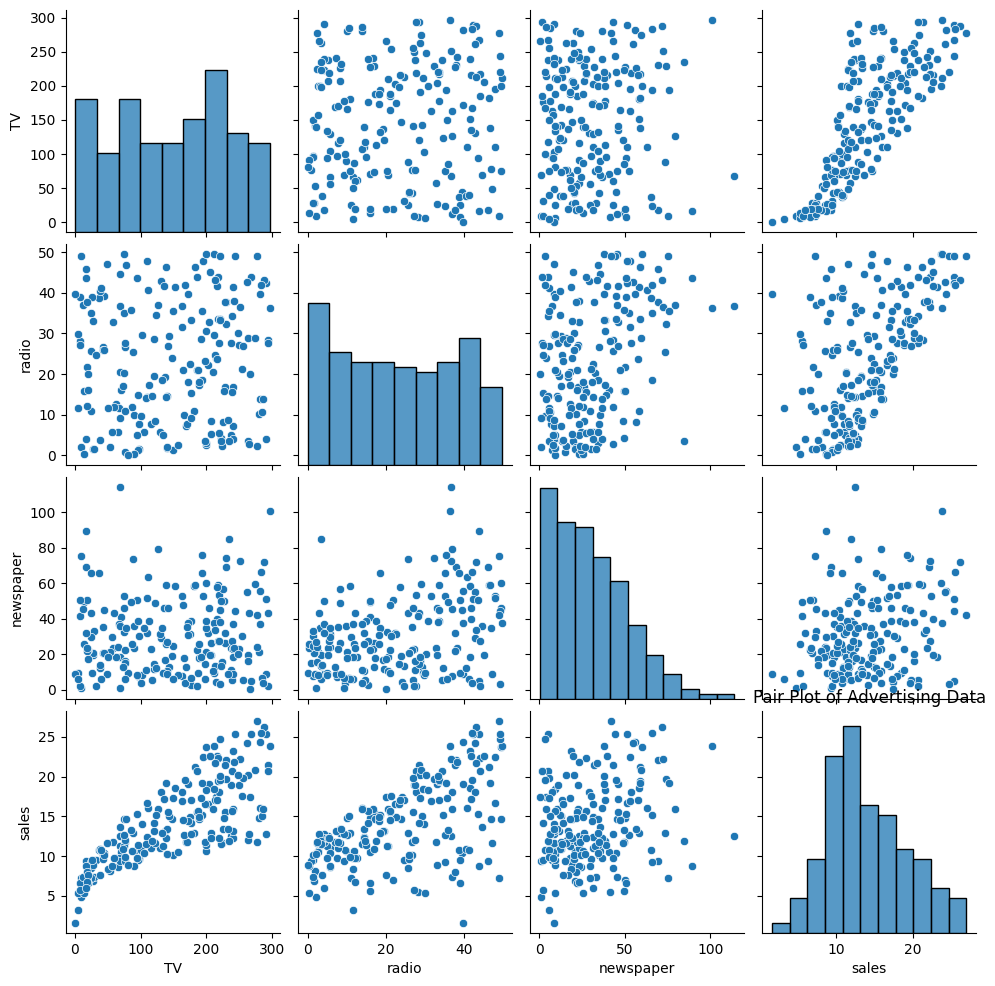


TRAIN-TEST SPLIT
Training features: (160, 3)
Testing features : (40, 3)
Training target  : (160,)
Testing target   : (40,)

LINEAR REGRESSION
Linear Regression completed.

POLYNOMIAL REGRESSION
Polynomial Regression completed.

SUPPORT VECTOR REGRESSION
SVR completed.


MODEL EVALUATION RESULTS

Linear Regression
-----------------
MAE  : 1.4607567168117603
MSE  : 3.1740973539761033
RMSE : 1.78159966153345

Polynomial Regression
---------------------
MAE  : 0.5261794444043838
MSE  : 0.41291022853790765
RMSE : 0.6425809120553673

Support Vector Regression
-------------------------
MAE  : 1.1621388310185972
MSE  : 2.8621091217425514
RMSE : 1.691776912522024


MODEL COMPARISON TABLE
                   Model       MAE       MSE      RMSE
0      Linear Regression  1.460757  3.174097  1.781600
1  Polynomial Regression  0.526179  0.412910  0.642581
2                    SVR  1.162139  2.862109  1.691777


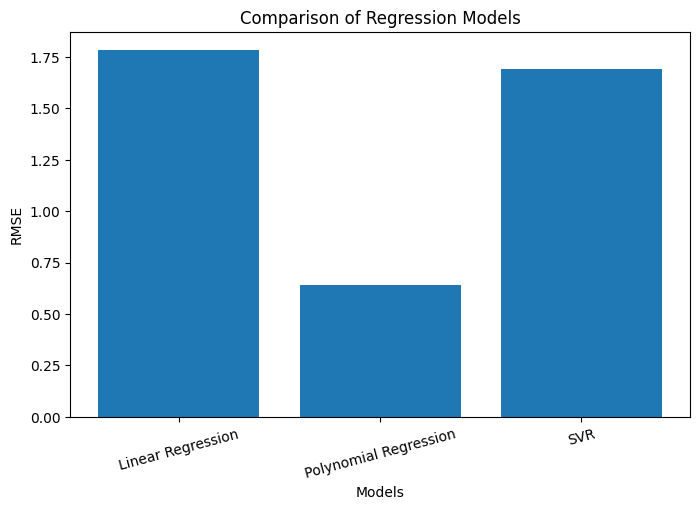



K-MEANS CLUSTERING

DATASET WITH CLUSTER LABELS
      TV  radio  newspaper  sales  Cluster
0  230.1   37.8       69.2   22.1        2
1   44.5   39.3       45.1   10.4        2
2   17.2   45.9       69.3    9.3        2
3  151.5   41.3       58.5   18.5        2
4  180.8   10.8       58.4   12.9        2
5    8.7   48.9       75.0    7.2        2
6   57.5   32.8       23.5   11.8        1
7  120.2   19.6       11.6   13.2        1
8    8.6    2.1        1.0    4.8        1
9  199.8    2.6       21.2   10.6        0

CLUSTER COUNTS
Cluster
1    75
0    65
2    60
Name: count, dtype: int64

CLUSTER CENTERS
           TV      radio  newspaper
0  220.083077  18.413846  18.687692
1   69.537333  15.933333  21.060000
2  164.796667  37.681667  55.276667


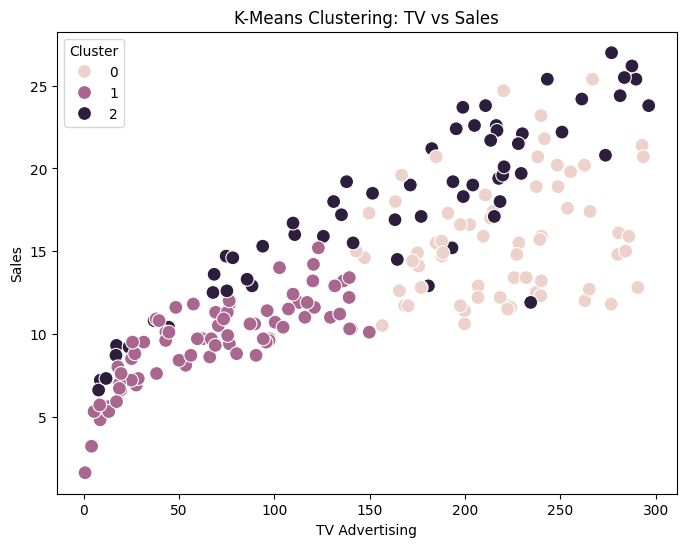



BEST MODEL
Best model based on RMSE: Polynomial Regression


CONCLUSION
Linear Regression, Polynomial Regression, and Support Vector Regression were applied.
The models were evaluated using MAE, MSE and RMSE.
K-Means clustering was performed using 3 clusters.
The clusters were visualized using TV versus Sales.


In [12]:
# ============================================================
# EX 3: MODEL PLANNING AND BUILDING
# AD23532 - PRINCIPLES OF DATA SCIENCE
# DATASET: ADVERTISING
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans


# ============================================================
# 2. LOAD ADVERTISING DATASET
# ============================================================

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)


# Remove unnecessary index column if present

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)


print("DATASET LOADED SUCCESSFULLY")


# ============================================================
# 3. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFIRST 5 ROWS")
print("===========")

print(df.head())


# ============================================================
# 4. CHECK DATASET SHAPE
# ============================================================

print("\nDATASET SHAPE")
print("=============")

print(df.shape)


# ============================================================
# 5. CHECK COLUMN NAMES
# ============================================================

print("\nCOLUMN NAMES")
print("===========")

print(df.columns)


# ============================================================
# 6. CHECK DATA TYPES
# ============================================================

print("\nDATA TYPES")
print("=========")

print(df.dtypes)


# ============================================================
# 7. CHECK NULL VALUES
# ============================================================

print("\nNULL VALUES")
print("===========")

print(df.isnull().sum())


# ============================================================
# 8. CHECK DUPLICATE VALUES
# ============================================================

print("\nDUPLICATE ROWS")
print("==============")

print(df.duplicated().sum())


# ============================================================
# 9. STATISTICAL SUMMARY
# ============================================================

print("\nSTATISTICAL SUMMARY")
print("===================")

print(df.describe())


# ============================================================
# 10. SELECT FEATURES AND TARGET
# ============================================================

X = df[['TV', 'radio', 'newspaper']]

y = df['sales']


print("\nFEATURES")
print("=======")

print(X.head())


print("\nTARGET")
print("======")

print(y.head())


# ============================================================
# 11. PAIR PLOT
# ============================================================

print("\nPAIR PLOT")

sns.pairplot(df)

plt.title("Pair Plot of Advertising Data")

plt.show()


# ============================================================
# 12. SPLIT DATA INTO TRAINING AND TESTING SETS
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42
                )


print("\nTRAIN-TEST SPLIT")
print("===============")

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)


# ============================================================
# 13. LINEAR REGRESSION
# ============================================================

print("\nLINEAR REGRESSION")
print("=================")


linear_model = LinearRegression()


# Train model

linear_model.fit(
    X_train,
        y_train
        )


# Predict

linear_pred = linear_model.predict(
    X_test
    )


print("Linear Regression completed.")


# ============================================================
# 14. POLYNOMIAL REGRESSION
# ============================================================

print("\nPOLYNOMIAL REGRESSION")
print("=====================")


poly_model = Pipeline([

        ('polynomial',
             PolynomialFeatures(degree=2)),

                     ('linear',
                          LinearRegression())
                          ])


# Train model

poly_model.fit(
    X_train,
        y_train
        )


# Predict

poly_pred = poly_model.predict(
    X_test
    )


print("Polynomial Regression completed.")


# ============================================================
# 15. SUPPORT VECTOR REGRESSION
# ============================================================

print("\nSUPPORT VECTOR REGRESSION")
print("=========================")


svr_model = Pipeline([

        ('scaler',
             StandardScaler()),

                     ('svr',
                          SVR(kernel='rbf'))
                          ])


# Train model

svr_model.fit(
    X_train,
        y_train
        )


# Predict

svr_pred = svr_model.predict(
    X_test
    )


print("SVR completed.")


# ============================================================
# 16. EVALUATE LINEAR REGRESSION
# ============================================================

linear_mae = mean_absolute_error(
    y_test,
        linear_pred
        )

linear_mse = mean_squared_error(
    y_test,
        linear_pred
        )

linear_rmse = np.sqrt(
    linear_mse
    )


# ============================================================
# 17. EVALUATE POLYNOMIAL REGRESSION
# ============================================================

poly_mae = mean_absolute_error(
    y_test,
        poly_pred
        )

poly_mse = mean_squared_error(
    y_test,
        poly_pred
        )

poly_rmse = np.sqrt(
    poly_mse
    )


# ============================================================
# 18. EVALUATE SVR
# ============================================================

svr_mae = mean_absolute_error(
    y_test,
        svr_pred
        )

svr_mse = mean_squared_error(
    y_test,
        svr_pred
        )

svr_rmse = np.sqrt(
    svr_mse
    )


# ============================================================
# 19. DISPLAY MODEL RESULTS
# ============================================================

print("\n\nMODEL EVALUATION RESULTS")
print("========================")


print("\nLinear Regression")
print("-----------------")
print("MAE  :", linear_mae)
print("MSE  :", linear_mse)
print("RMSE :", linear_rmse)


print("\nPolynomial Regression")
print("---------------------")
print("MAE  :", poly_mae)
print("MSE  :", poly_mse)
print("RMSE :", poly_rmse)


print("\nSupport Vector Regression")
print("-------------------------")
print("MAE  :", svr_mae)
print("MSE  :", svr_mse)
print("RMSE :", svr_rmse)


# ============================================================
# 20. MODEL COMPARISON TABLE
# ============================================================

results = pd.DataFrame({

    'Model': [
            'Linear Regression',
                    'Polynomial Regression',
                            'SVR'
                                ],

                                'MAE': [
                                        linear_mae,
                                                poly_mae,
                                                        svr_mae
                                                            ],

                                                                'MSE': [
                                                                        linear_mse,
                                                                                poly_mse,
                                                                                        svr_mse
                                                                                            ],

                                                                                                'RMSE': [
                                                                                                        linear_rmse,
                                                                                                                poly_rmse,
                                                                                                                        svr_rmse
                                                                                                                            ]

                                                                                                                            })


print("\n\nMODEL COMPARISON TABLE")
print("======================")

print(results)


# ============================================================
# 21. SINGLE BAR GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results['Model'],
        results['RMSE']
        )

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.title(
    "Comparison of Regression Models"
    )

plt.xticks(rotation=15)

plt.show()


# ============================================================
# 22. K-MEANS CLUSTERING
# ============================================================

print("\n\nK-MEANS CLUSTERING")
print("==================")


# Select features

cluster_features = df[
    ['TV', 'radio', 'newspaper']
    ]


# ============================================================
# 23. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_features
    )


# ============================================================
# 24. APPLY K-MEANS WITH 3 CLUSTERS
# ============================================================

kmeans = KMeans(
    n_clusters=3,
        random_state=42,
            n_init=10
            )


# Fit K-Means

kmeans.fit(
    cluster_scaled
    )


# ============================================================
# 25. ADD CLUSTER LABELS
# ============================================================

df['Cluster'] = kmeans.labels_


print("\nDATASET WITH CLUSTER LABELS")
print("===========================")

print(df.head(10))


# ============================================================
# 26. DISPLAY CLUSTER COUNTS
# ============================================================

print("\nCLUSTER COUNTS")
print("==============")

print(
    df['Cluster'].value_counts()
    )


# ============================================================
# 27. DISPLAY CLUSTER CENTERS
# ============================================================

print("\nCLUSTER CENTERS")
print("===============")

cluster_centers = scaler.inverse_transform(
    kmeans.cluster_centers_
    )

cluster_centers_df = pd.DataFrame(
    cluster_centers,
        columns=[
                'TV',
                        'radio',
                                'newspaper'
                                    ]
                                    )

print(cluster_centers_df)


# ============================================================
# 28. VISUALIZE CLUSTERS
# TV VS SALES
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
        x='TV',
            y='sales',
                hue='Cluster',
                        s=100
                        )

plt.xlabel("TV Advertising")

plt.ylabel("Sales")

plt.title(
    "K-Means Clustering: TV vs Sales"
    )

plt.show()


# ============================================================
# 29. FIND BEST MODEL
# ============================================================

best_model = results.loc[
    results['RMSE'].idxmin(),
        'Model'
        ]


print("\n\nBEST MODEL")
print("=========")

print(
    "Best model based on RMSE:",
        best_model
        )


# ============================================================
# 30. FINAL CONCLUSION
# ============================================================

print("\n\nCONCLUSION")
print("=========")

print(
    "Linear Regression, Polynomial Regression, "
        "and Support Vector Regression were applied."
        )

print(
    "The models were evaluated using "
        "MAE, MSE and RMSE."
        )

print(
    "K-Means clustering was performed using "
        "3 clusters."
        )

print(
    "The clusters were visualized using "
        "TV versus Sales."
        )